**EJERCICIO 1: NIVEL DE ESTRES**

Contexto: Queremos predecir si un estudiante presenta estrés basándonos en sus hábitos.

Variables:

Sueño (Poco, Suficiente)
Ejercicio (Sí, No)
Carga_Tareas (Alta, Normal)
Estrés ← variable objetivo (Sí, No)

In [32]:
import pandas as pd
import numpy as np
import math
from collections import Counter
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

In [33]:
df = pd.DataFrame({
    "Sueño": ["Poco","Poco","Poco","Suficiente",
              "Suficiente","Suficiente","Poco","Suficiente"],

    "Ejercicio": ["No","No","Sí","No",
                  "Sí","Sí","Sí","No"],

    "Carga_Tareas": ["Alta","Normal","Alta","Alta",
                     "Normal","Alta","Normal","Normal"],

    "Estrés": ["Sí","Sí","Sí","Sí",
               "No","No","No","No"]
})

In [34]:
print(df)

        Sueño Ejercicio Carga_Tareas Estrés
0        Poco        No         Alta     Sí
1        Poco        No       Normal     Sí
2        Poco        Sí         Alta     Sí
3  Suficiente        No         Alta     Sí
4  Suficiente        Sí       Normal     No
5  Suficiente        Sí         Alta     No
6        Poco        Sí       Normal     No
7  Suficiente        No       Normal     No


In [35]:
def entropia(columna):
    valores = Counter(columna)
    total = len(columna)

    ent = 0

    for v in valores.values():
        p = v / total
        ent -= p * math.log2(p)

    return ent

In [36]:
def ganancia_informacion(df, atributo, objetivo):

    ent_total = entropia(df[objetivo])

    ent_atributo = 0

    for valor in df[atributo].unique():

        subset = df[df[atributo] == valor]

        peso = len(subset) / len(df)

        ent_atributo += peso * entropia(subset[objetivo])

    return ent_total - ent_atributo

 ENTROPÍA TOTAL

In [37]:
ent_total = entropia(df["Estrés"])
print(f"Entropía = {ent_total:.4f}")

Entropía = 1.0000


Calcular la ganancia de información de cada atributo

In [38]:
atributos = ["Sueño","Ejercicio","Carga_Tareas"]
ganancias = {}
for atributo in atributos:
    gain = ganancia_informacion(df, atributo, "Estrés")
    ganancias[atributo] = gain

    print(f"{atributo}: {gain:.4f}")

Sueño: 0.1887
Ejercicio: 0.1887
Carga_Tareas: 0.1887


Identificar el nodo raíz.

In [39]:
raiz = max(ganancias, key=ganancias.get)
print("Nodo raiz:", raiz)

Nodo raiz: Sueño


Construir el árbol completo.

In [40]:
encoder = LabelEncoder()
df_ml = df.copy()
for col in df_ml.columns:
    df_ml[col] = encoder.fit_transform(df_ml[col])

X = df_ml.drop("Estrés", axis=1)
y = df_ml["Estrés"]

modelo = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

modelo.fit(X, y)

DecisionTreeClassifier(criterion='entropy', random_state=42)

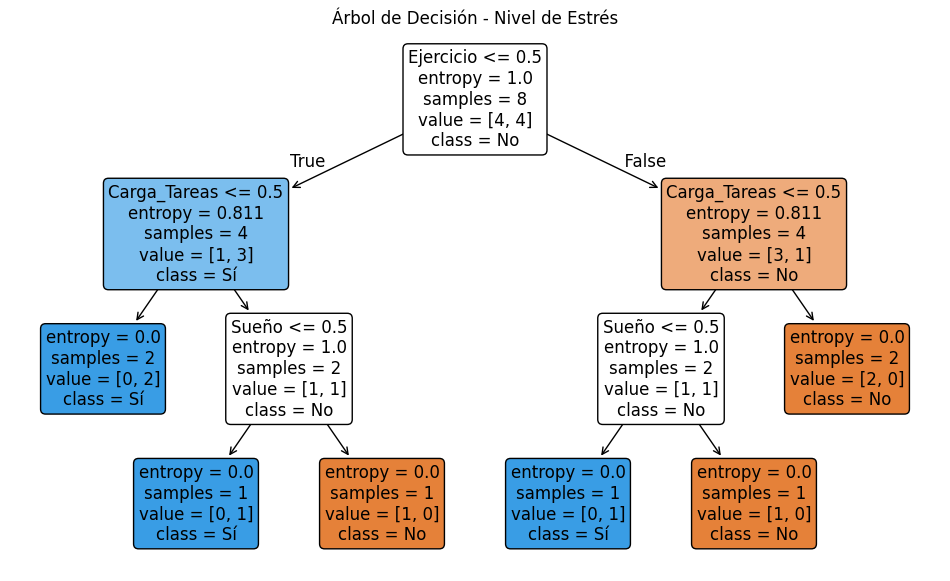

In [41]:
plt.figure(figsize=(12,7))
plot_tree(
    modelo,
    feature_names=["Sueño","Ejercicio","Carga_Tareas"],
    class_names=["No","Sí"],
    filled=True,
    rounded=True
)

plt.title("Árbol de Decisión - Nivel de Estrés")
plt.show()

Predecir: ¿Un estudiante con Sueño=Poco, Ejercicio=No, Carga=Alta tiene estrés?

In [42]:
pred = modelo.predict([[0,0,0]])
print("Sueño=Poco, Ejercicio=No, Carga=Alta")
print("Resultado:", "Sí" if pred[0] == 1 else "No")

Sueño=Poco, Ejercicio=No, Carga=Alta
Resultado: Sí


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
